# Ising analítico

Este notebook contiene las soluciones analíticas, tq,

- Ising 1D con matriz de transferencia — derivación compacta y evaluación numérica.
- Ising 2D de Onsager — magnetización espontánea analítica para $h=0$.


## I. Ising 1D — teoría cóncicsa.

Consideramos la cadena de Ising clásica con energía

$$H = -J\sum_{i=1}^N s_i s_{i+1} - h \sum_{i=1}^N s_i,\qquad s_i=\pm1$$

La matriz de transferencia $T$ es $2\times2$ y sus entradas son

$$T_{s,s'} = e^{\beta (Jss' + \tfrac{h}{2}(s+s'))},\quad s,s'\in\{+1,-1\}.$$ 

La función de partición es $Z=\mathrm{Tr}(T^N)$ y en el límite grande $N$ domina $\lambda_{\max}^N$, donde $\lambda_{\max}$ es el mayor autovalor de $T$.

La magnetización por sitio se obtiene mediante

$$m = \frac{1}{\beta}\partial_{h} \log \lambda_{\max} = \partial_{(\beta h)} \log \lambda_{\max} .$$


### Gráfica: magnetización 1D vs temperatura

A continuación generamos la gráfica de $m(T)$ para varios campos externos. Cambiá `J`, `hs` o el rango `T_vals` si querés experimentar.

In [8]:
import numpy as np
from typing import Tuple, Optional
import matplotlib.pyplot as plt
from scipy.sparse import diags, kron, identity
from scipy.sparse.linalg import eigsh

In [9]:
# Funciones analíticas para Ising 1D (transfer matrix)
import numpy as np

def lambda_plus(beta, h, J=1.0):
    bJ = beta * J
    bh = beta * h
    e2bJ = np.exp(2 * bJ)
    term = e2bJ * np.sinh(bh)**2 + np.exp(-2 * bJ)
    return np.exp(bJ) * np.cosh(bh) + np.sqrt(term)

def magnetization_1d(beta, h, J=1.0):
    # derivada analítica de lambda_plus respecto a (beta*h)
    bJ = beta * J
    bh = beta * h
    e2bJ = np.exp(2 * bJ)
    sqrt_arg = e2bJ * np.sinh(bh)**2 + np.exp(-2 * bJ)
    lam = lambda_plus(beta, h, J)
    dl_dbh = np.exp(bJ) * np.sinh(bh) + (e2bJ * np.sinh(bh) * np.cosh(bh)) / np.sqrt(sqrt_arg)
    return dl_dbh / lam

# Probar funciones
beta = 2.0
for h in [0.0, 0.1, 0.5]:
    print(f"beta={beta}, h={h} -> m_1D = {magnetization_1d(beta,h):.6f}")

beta=2.0, h=0.0 -> m_1D = 0.000000
beta=2.0, h=0.1 -> m_1D = 0.995888
beta=2.0, h=0.5 -> m_1D = 0.999879


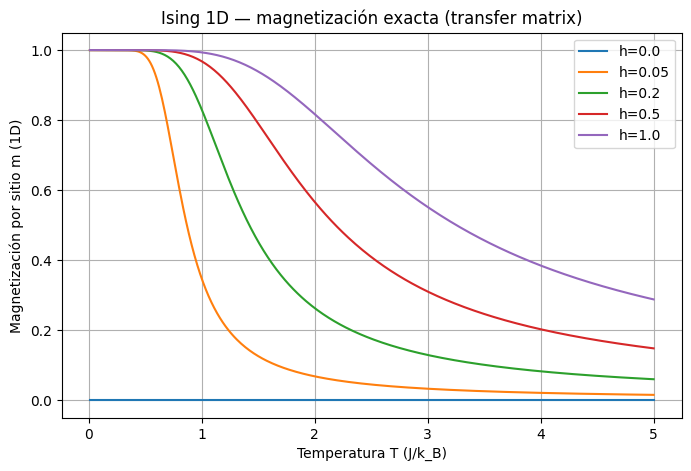

In [10]:
import matplotlib.pyplot as plt
J = 1.0
kB = 1.0
T_vals = np.linspace(0.01, 5.0, 400)
hs = [0.0, 0.05, 0.2, 0.5, 1.0]

plt.figure(figsize=(8,5))
for h in hs:
    m_vals = np.array([magnetization_1d(1.0/(kB*T), h, J) for T in T_vals])
    plt.plot(T_vals, m_vals, label=f"h={h}")
plt.xlabel("Temperatura T (J/k_B)")
plt.ylabel("Magnetización por sitio m (1D)")
plt.title("Ising 1D — magnetización exacta (transfer matrix)")
plt.legend()
plt.grid(True)
plt.show()

## II. Ising 2D — magnetización espontánea (Onsager)

Para la red cuadrada ferromagnética sin campo ($h=0$), la magnetización espontánea para $T<T_c$ es

$$m(T)=\left[1-\sinh^{-4}(2\beta J)\right]^{1/8},\qquad \beta=1/(k_B T).$$

La temperatura crítica satisface $\sinh(2\beta_c J)=1$, i.e. $k_B T_c = \dfrac{2J}{\ln(1+\sqrt{2})}$.

En la celda siguiente generamos la gráfica de $m(T)$ y marcamos $T_c$.

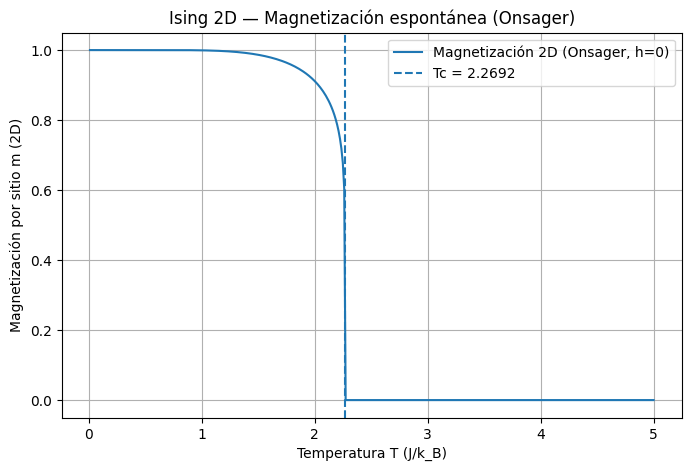

In [11]:
def magnetization_2d(T, J=1.0, kB=1.0):
    T = np.array(T, dtype=float)
    beta = 1.0 / (kB * T)
    x = np.sinh(2 * beta * J)
    m = np.zeros_like(T)
    with np.errstate(divide='ignore', invalid='ignore'):
        val = 1.0 - x**(-4)
        val[val < 0] = 0.0
        m[x > 1.0] = val[x > 1.0]**(1.0/8.0)
    return m

# Parámetros y gráfico
J = 1.0
kB = 1.0
T_vals = np.linspace(0.01, 5.0, 400)
m2 = magnetization_2d(T_vals, J, kB)
Tc = 2.0 * J / np.log(1.0 + np.sqrt(2.0))

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(T_vals, m2, label="Magnetización 2D (Onsager, h=0)")
plt.axvline(Tc, linestyle='--', label=f"Tc = {Tc:.4f}")
plt.xlabel("Temperatura T (J/k_B)")
plt.ylabel("Magnetización por sitio m (2D)")
plt.title("Ising 2D — Magnetización espontánea (Onsager)")
plt.legend()
plt.grid(True)
plt.show()

## III. Comparación y notas numéricas

- **Ising 1D:** no hay transición de fase a $T>0$ cuando $h=0$, se observaría que $m\to0$ con $h\to0$ salvo en $T=0$. Para campos finitos existe magnetización inducida.
- **Ising 2D:** aparición de magnetización espontánea por debajo de $T_c$, cuya solución es de Onsager.

### Notas de estabilidad numérica
- Evitar evaluar`T` demasiado cercano a 0 sin control puede generar discontinuanidades y problemas en exponenciales.
- Para 2D, la fórmula de Onsager es sensible muy cerca de $T_c$ por potencias fraccionarias; usar mayor resolución en `T_vals` si se desea estudiar el comportamiento crítico.